In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# A molecular weight from a column of liquid (Illustrations 11.5-1 and 11.5-2)

Two osmometry reductions, deliberately side by side because they are the same
measurement analyzed two different ways.

**Illustration 11.5-1** is one point. Two grams of polyvinyl chloride per liter of
cyclohexanone lifts the solvent 0.85 cm, and that single height gives a molecular
weight of 60 670 g/mol.

**Illustration 11.5-2** is seven points. Seven osmotic pressures of serum albumin are
turned into seven molecular weights, which are then averaged to about 74 500 g/mol.

**What the contrast shows.** Section 11.5 says explicitly what to do with several
measurements -- *"the limiting value of $C_{\rm solute}/\Pi$ as $C_{\rm solute}$
approaches zero is used"* -- and Illustration 11.5-2 does something else: it averages
seven values of $C/\Pi$ that are not the limiting one. The notebook does both and
reports the difference, which for this data set is small and for the
$\alpha$-chymotrypsin data of Illustration 11.5-3 is not.

**And one thing neither illustration says.** Polyvinyl chloride is not a single
molecule; a batch of it is a distribution of chain lengths. Osmometry returns a
particular average of that distribution, and which average it is follows in one line
from Eq. 11.5-6. The last cell derives it numerically.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.charts import use_book_style
from thermo.osmotic import (pressure_from_height, molecular_weight, virial_fit,
                            osmotic_pressure_dilute, multicomponent_dilute)

use_book_style()

# --- Illustration 11.5-1: PVC in cyclohexanone at 25 C ----------------------
RHO_CYCLOHEXANONE = 980.0      # kg/m^3, printed as 0.98 g/cm^3
H_RISE = 0.0085                # m, printed as 0.85 cm
C_PVC = 2.0                    # g/L
T_PVC = 298.15

Pi = pressure_from_height(RHO_CYCLOHEXANONE, H_RISE)
m_PVC = molecular_weight(C_PVC, Pi, T_PVC)

print("  Illustration 11.5-1, PVC in cyclohexanone")
print(f"    Pi = rho g h = {RHO_CYCLOHEXANONE:.0f} x 9.81 x {H_RISE:.4f}"
      f" = {Pi:.2f} Pa            SIS 81.72")
print(f"    m  = RT C / Pi = {m_PVC:,.0f} g/mol"
      f"                          SIS 60 670")

# The section's own worked example, one paragraph earlier: 1 g of a 60 000 g/mol
# macromolecule in 100 mL of water at 25 C. It is here as a check on the machinery
# against a number SIS reports in two different units.
Pi_ex = osmotic_pressure_dilute(10.0, 60000.0, 298.15)
print(f"\n  The section's own example, 1 g of 60 000 g/mol in 100 mL of water:")
print(f"    Pi = {Pi_ex:.1f} Pa = {Pi_ex/1e5:.3e} bar"
      f"      SIS 4.13e-3 bar")
print(f"       = {Pi_ex/(1000*9.81)*100:.2f} cm of water"
      f"             SIS 4.22 cm H2O")

  Illustration 11.5-1, PVC in cyclohexanone
    Pi = rho g h = 980 x 9.81 x 0.0085 = 81.72 Pa            SIS 81.72
    m  = RT C / Pi = 60,672 g/mol                          SIS 60 670

  The section's own example, 1 g of 60 000 g/mol in 100 mL of water:
    Pi = 413.2 Pa = 4.132e-03 bar      SIS 4.13e-3 bar
       = 4.21 cm of water             SIS 4.22 cm H2O



## Seven points, and a unit that does not survive being checked

Illustration 11.5-2 gives seven pairs of albumin concentration and osmotic pressure at
0 °C, with the concentration column headed **$C$ (g/cc)** and the pressure column in
centimeters of water. It then prints a $C/\Pi$ column and a molecular weight for each
row.

The molecular weight column is what makes the units checkable: $m_S = RT\,C_S/\Pi$ has
only one unknown in it once $\Pi$ is converted out of centimeters. Running it in each of
the three candidate units shows which one the printed column was computed in.

In [3]:

# --- Illustration 11.5-2: bovine serum albumin, pH 4.8, 0.05 M acetate, 0 C ---
# The concentration column as printed, whatever its units are, and the heights.
C_ALB = np.array([0.78, 1.25, 2.79, 3.38, 4.18, 8.98, 12.45])
H_ALB = np.array([2.39, 4.01, 8.53, 10.80, 13.01, 27.84, 37.69])     # cm H2O
SIS_RATIO = np.array([0.3264, 0.3117, 0.3271, 0.3127, 0.3213, 0.3226, 0.3303])
SIS_MW = np.array([75600, 72400, 75700, 72600, 74400, 74700, 76600])
T_ALB = 273.15

PI_ALB = pressure_from_height(1000.0, H_ALB / 100.0)     # Pa

print("  Which unit reproduces the printed molecular weights?")
print(f"  {'reading of the C column':26s} {'mean m_S (g/mol)':>18s} {'worst row':>12s}")
for factor, name in ((1.0, "g/L as printed"), (10.0, "g/dL, i.e. g per 100 mL"),
                     (1000.0, "g/cc, the printed header")):
    m = molecular_weight(C_ALB * factor, PI_ALB, T_ALB)
    worst = np.max(np.abs(m / SIS_MW - 1))
    print(f"  {name:26s} {m.mean():18,.0f} {100*worst:11.1f} %")
print(f"  {'SIS prints':26s} {SIS_MW.mean():18,.0f}")

  Which unit reproduces the printed molecular weights?
  reading of the C column      mean m_S (g/mol)    worst row
  g/L as printed                          7,449        90.0 %
  g/dL, i.e. g per 100 mL                74,489         0.3 %
  g/cc, the printed header            7,448,940      9902.9 %
  SIS prints                             74,571


In [4]:

# g/dL it is; the rest of this notebook uses it.
C_ALB_gL = C_ALB * 10.0

print("  Illustration 11.5-2 recomputed, C in g/dL")
print(f"  {'C (g/dL)':>9s} {'h (cm)':>7s} {'Pi (Pa)':>8s} {'C/Pi':>7s} {'SIS':>7s}"
      f" {'m_S':>9s} {'SIS':>8s}")
m_rows = molecular_weight(C_ALB_gL, PI_ALB, T_ALB)
for C, h, P, r, sr, m, sm in zip(C_ALB, H_ALB, PI_ALB, C_ALB / H_ALB, SIS_RATIO,
                                 m_rows, SIS_MW):
    print(f"  {C:9.2f} {h:7.2f} {P:8.1f} {r:7.4f} {sr:7.4f} {m:9,.0f} {sm:8,d}")
print(f"\n  average {m_rows.mean():,.0f} g/mol against SIS's 'approximately 74 500'"
      f" (its own seven average to {SIS_MW.mean():,.0f})")
print(f"  every row within {100*np.max(np.abs(m_rows/SIS_MW - 1)):.2f} % of the"
      f" printed value")
print(f"\n  one printed C/Pi does not match: row 4, {C_ALB[3]}/{H_ALB[3]} ="
      f" {C_ALB[3]/H_ALB[3]:.4f}, printed {SIS_RATIO[3]:.4f}")

  Illustration 11.5-2 recomputed, C in g/dL
   C (g/dL)  h (cm)  Pi (Pa)    C/Pi     SIS       m_S      SIS
       0.78    2.39    234.5  0.3264  0.3264    75,555   75,600
       1.25    4.01    393.4  0.3117  0.3117    72,166   72,400
       2.79    8.53    836.8  0.3271  0.3271    75,722   75,700
       3.38   10.80   1059.5  0.3130  0.3127    72,453   72,600
       4.18   13.01   1276.3  0.3213  0.3213    74,382   74,400
       8.98   27.84   2731.1  0.3226  0.3226    74,675   74,700
      12.45   37.69   3697.4  0.3303  0.3303    76,473   76,600

  average 74,489 g/mol against SIS's 'approximately 74 500' (its own seven average to 74,571)
  every row within 0.32 % of the printed value

  one printed C/Pi does not match: row 4, 3.38/10.8 = 0.3130, printed 0.3127



**The concentration column is in g/dL, not g/cc.** Read as g/cc it gives molecular
weights of seven million; read as g/L it gives seven thousand; read as grams per 100 mL
it reproduces all seven printed values to better than a third of a percent. A factor of
100 has gone missing from the column heading, and the printed molecular weights are the
evidence -- which is the useful thing about a table that carries a redundant column.

The magnitudes agree with that reading too. Twelve grams per deciliter of albumin is
concentrated but real -- blood plasma is about 4 g/dL -- while 12 g/cc is denser than
lead.

The data set is also the one uncited table in these two sections: it is introduced
with *"have been reported"* and no footnote, where every other data set in §11.4 and
§11.5 carries one.

In [5]:

# The section's own instruction, applied: extrapolate rather than average.
lin = virial_fit(C_ALB_gL, PI_ALB, T_ALB, order=1)
quad = virial_fit(C_ALB_gL, PI_ALB, T_ALB, order=2)

print("  Average of the seven single-point values:")
print(f"    {m_rows.mean():,.0f} g/mol, spread {m_rows.min():,.0f} to {m_rows.max():,.0f}")
print("\n  Extrapolated to zero concentration instead, as Sec. 11.5 directs:")
for f, name in ((lin, "straight line"), (quad, "quadratic")):
    print(f"    {name:14s} m_S = {f.m_S:,.0f} +/- {f.m_S_stderr:,.0f} g/mol,"
          f"  B_2 = {f.B2:+.1f} L/mol,  rms {f.rms(C_ALB_gL, PI_ALB):.2f} Pa L/g")

print("\n  The two agree here, and the next cell shows why.")

  Average of the seven single-point values:
    74,489 g/mol, spread 72,166 to 76,473

  Extrapolated to zero concentration instead, as Sec. 11.5 directs:
    straight line  m_S = 73,581 +/- 924 g/mol,  B_2 = -17.9 L/mol,  rms 0.55 Pa L/g
    quadratic      m_S = 74,413 +/- 1,654 g/mol,  B_2 = +27.1 L/mol,  rms 0.53 Pa L/g

  The two agree here, and the next cell shows why.


  Pi/C_S over the seven points: [30.06 31.47 29.99 31.35 30.53 30.41 29.7 ]
  it moves 6 % up and down rather than one way; correlation with C_S is -0.48

  Illustration 11.5-3, the same two reductions:
    average of the six single points 32,577 g/mol, extrapolated 29,498
    a 10 % difference, against 1 % for the albumin data
    because there Pi/C_S falls monotonically by 15 %


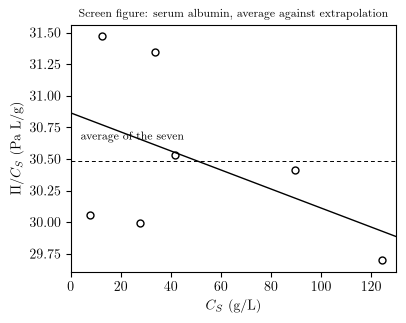

In [6]:
ratio = PI_ALB / C_ALB_gL
print(f"  Pi/C_S over the seven points: {np.round(ratio, 2)}")
print(f"  it moves {100*(ratio.max()-ratio.min())/ratio.mean():.0f} % up and down"
      f" rather than one way; correlation with C_S is"
      f" {np.corrcoef(C_ALB_gL, ratio)[0,1]:+.2f}")

# The same comparison on Illustration 11.5-3's data, where the trend is real.
C_CHY = np.array([0.902, 1.798, 3.574, 5.331, 7.027, 8.835])
PI_CHY = np.array([74.8, 142.3, 276.2, 398.0, 513.3, 625.3])
m_chy_rows = molecular_weight(C_CHY, PI_CHY, 298.15)
chy = virial_fit(C_CHY, PI_CHY, 298.15, order=2)
print(f"\n  Illustration 11.5-3, the same two reductions:")
print(f"    average of the six single points {m_chy_rows.mean():,.0f} g/mol,"
      f" extrapolated {chy.m_S:,.0f}")
print(f"    a {100*(m_chy_rows.mean()/chy.m_S - 1):.0f} % difference, against"
      f" {100*(m_rows.mean()/lin.m_S - 1):.0f} % for the albumin data")
print(f"    because there Pi/C_S falls monotonically by"
      f" {100*(1 - PI_CHY[-1]/C_CHY[-1]/(PI_CHY[0]/C_CHY[0])):.0f} %")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
grid = np.linspace(0, 130, 200)
ax.plot(C_ALB_gL, ratio, "o", mfc="none", color="k", ms=5)
ax.plot(grid, lin.pi_over_C(grid), "-", color="k", lw=1.0)
ax.axhline(8.314e3 * T_ALB / m_rows.mean(), color="k", lw=0.7, ls=(0, (4, 3)))
ax.text(4, 8.314e3 * T_ALB / m_rows.mean() + 0.15,
        "average of the seven", fontsize=8, va="bottom")
ax.set_xlabel(r"$C_S$ (g/L)")
ax.set_ylabel(r"$\Pi/C_S$ (Pa L/g)")
ax.set_xlim(0, 130)
ax.set_title("Screen figure: serum albumin, average against extrapolation", fontsize=8)
plt.show()

## Which average does an osmometer report?

A batch of polymer is a mixture of chain lengths, so Illustration 11.5-1's "molecular
weight of the PVC polymer" is an average of a distribution. Equation 11.5-6 settles
which one without any new physics: in the dilute limit each species contributes
independently,

$$\Pi = RT\sum_i \frac{C_i}{m_i}$$

so a mixture and a single pure species produce the same osmotic pressure when
$\sum_i C_i/m_i$ is the same. Solving for the equivalent single molecular weight,

$$m_{\rm eq} = \frac{\sum_i C_i}{\sum_i C_i/m_i} = \frac{\sum_i N_i m_i}{\sum_i N_i}$$

which is the **number**-average molecular weight $M_n$: every molecule counts once,
whatever its size. Light scattering weights by mass instead and returns the larger
weight-average $M_w$, and the ratio $M_w/M_n$ is how broad the distribution is.

The cell below checks that claim by brute force on three distributions built to share
one $M_n$ -- a single chain length, two differing fourfold in size, and five spanning a
factor of twenty.

In [7]:
def averages(m, N):
    """Number- and weight-average molecular weight of a distribution."""
    m, N = np.asarray(m, float), np.asarray(N, float)
    Mn = np.sum(N * m) / np.sum(N)
    Mw = np.sum(N * m**2) / np.sum(N * m)
    return Mn, Mw


def batch(relative_sizes, mole_numbers, Mn_target=60670.0):
    """A distribution with a given number-average molecular weight.

    `relative_sizes` fixes the *shape* and the scale is then set so that M_n comes
    out at `Mn_target` -- which is the only way to compare distributions of different
    breadth at fixed M_n without solving for a chain length by hand.
    """
    r = np.asarray(relative_sizes, float)
    N = np.asarray(mole_numbers, float)
    m = r * Mn_target / (np.sum(N * r) / np.sum(N))
    return m, N


CASES = {
    "monodisperse": batch([1.0], [1.0]),
    "two chain lengths, 4:1 in size": batch([0.5, 2.0], [2.0, 1.0]),
    "five chain lengths, 20:1": batch([0.25, 0.5, 1.0, 2.0, 5.0], np.ones(5)),
}

print(f"  {'batch':32s} {'M_n':>9s} {'M_w':>9s} {'M_w/M_n':>8s} {'Pi (Pa)':>9s}")
for name, (m, N) in CASES.items():
    Mn, Mw = averages(m, N)
    # split the same 2 g/L of total polymer among the species by mass
    mass = N * m
    C_i = C_PVC * mass / mass.sum()
    Pi_mix = multicomponent_dilute(C_i, m, T_PVC)
    print(f"  {name:32s} {Mn:9,.0f} {Mw:9,.0f} {Mw/Mn:8.2f} {Pi_mix:9.2f}")

print(f"\n  All three have the same number-average molecular weight and"
      f" polydispersities")
print(f"  of 1.0, 1.5 and 2.0, and all three produce the same osmotic pressure to the")
print(f"  last digit printed. An osmometer measures M_n and is blind to the rest of the")
print(f"  distribution -- so Illustration 11.5-1's 60 670 g/mol is a number average,")
print(f"  and a light-scattering measurement on the same three batches would return")
print(f"  {', '.join(f'{averages(*v)[1]:,.0f}' for v in CASES.values())} g/mol.")

  batch                                  M_n       M_w  M_w/M_n   Pi (Pa)
  monodisperse                        60,670    60,670     1.00     81.72
  two chain lengths, 4:1 in size      60,670    91,005     1.50     81.72
  five chain lengths, 20:1            60,670   120,102     1.98     81.72

  All three have the same number-average molecular weight and polydispersities
  of 1.0, 1.5 and 2.0, and all three produce the same osmotic pressure to the
  last digit printed. An osmometer measures M_n and is blind to the rest of the
  distribution -- so Illustration 11.5-1's 60 670 g/mol is a number average,
  and a light-scattering measurement on the same three batches would return
  60,670, 91,005, 120,102 g/mol.



## Your turn

1. Illustration 11.5-1 reports one significant figure of height, 0.85 cm. Propagate a
   reading error of $\pm 0.05$ cm through to the molecular weight. Is 60 670 g/mol
   defensible to five figures?
2. The PVC measurement is at a single concentration, 2 g/L. Suppose the polymer has the
   same $B_2$ as $\alpha$-chymotrypsin per gram, $-782$ L/mol at $m_S = 29\,500$. How
   much would the single-point value be in error, and in which direction?
3. Osmometry is one of several routes to a macromolecular molecular weight. Section 11.5
   compares it with freezing-point depression: for the 60 000 g/mol protein at
   0.01 g/mL the depression is 0.00031 K. Work out what precision a thermometer would
   need for 1 % accuracy in $m_S$, and compare it with reading a meniscus to a
   millimeter.
4. Redo the albumin reduction using the *solution* density rather than 1000 kg/m³ in
   $\Pi = \rho g h$. At 12.45 g/dL the solution is about 3 % denser than water. Does the
   correction move the answer more or less than the scatter between rows?
5. Build a log-normal chain-length distribution with $M_n = 60\,670$ and
   $M_w/M_n = 2$, and confirm that its osmotic pressure at 2 g/L matches the
   monodisperse case above. Then compute what a light-scattering experiment would
   report for the same batch.